# Rank Tests for Two Groups: Mann-Whitney U and Wilcoxon Signed-Rank

## Overview

These are the standard nonparametric alternatives to the two-sample and paired t-tests. They replace raw values with ranks, making them robust to non-normality, outliers, and ordinal data.

| Test | Parametric analog | Data structure | Null hypothesis |
|---|---|---|---|
| **Mann-Whitney U** (Wilcoxon rank-sum) | Independent samples t-test | Two independent groups | The distributions of the two groups are identical; equivalently, P(X > Y) = 0.5 |
| **Wilcoxon signed-rank** | Paired t-test | Paired / repeated measures | The distribution of pairwise differences is symmetric around zero |

> **Note on the null hypothesis:**  
> These tests are often described as testing for equal medians — but this is only strictly true if the distributions have the same shape. The correct null is stochastic equality: that a randomly drawn value from group A is equally likely to exceed a value from group B as vice versa.

## When to Use

- Response is continuous but clearly non-normal and sample size is too small for the CLT to rescue the t-test (n < ~20–30)
- Response is ordinal (e.g., Likert scale, ranked scores)
- Data contain outliers that cannot be removed or transformed
- The t-test assumption of equal (or known) variance is implausible and Welch's correction is insufficient

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Comparing invertebrate counts between two habitat types when counts are zero-inflated or highly skewed; comparing ordinal habitat quality scores |
| **Healthcare** | Comparing pain scores (ordinal VAS scale) between treatment and control; comparing biomarker levels when sample size is small |
| **Finance** | Comparing return distributions between two portfolio strategies when returns are fat-tailed |
| **Insurance** | Comparing claim amounts between two risk categories when amounts are highly skewed |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(coin)        # independence_test(), wilcox_test() — exact and asymptotic
library(rstatix)     # wilcox_test(), cohens_d() — tidy wrappers
library(ggpubr)      # stat_compare_means() for adding p-values to plots
library(effectsize)  # rank_biserial(), cohens_d()

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'coin' was built under R version 4.4.3"
Loading required package: survival

Warning message:
"package 'surv

## Data

We use two simulated datasets to demonstrate each test:
1. **Invertebrate counts** — two independent habitats, overdispersed and zero-inflated (Mann-Whitney scenario)
2. **Water quality scores** — the same 20 sites assessed before and after restoration (Wilcoxon signed-rank scenario)

In [2]:
# ── Independent groups: invertebrate counts by habitat ────────────────────────
n <- 25
two_group <- tibble(
  count   = c(MASS::rnegbin(n, mu = 8,  theta = 1.2),
              MASS::rnegbin(n, mu = 22, theta = 1.2)),
  habitat = rep(c("degraded", "reference"), each = n)
)

# ── Paired: water quality score before/after restoration ─────────────────────
n_paired <- 20
paired_data <- tibble(
  site   = paste0("site", 1:n_paired),
  before = round(runif(n_paired, 2, 6)),    # ordinal 1–10
  after  = pmin(before + round(runif(n_paired, 0, 4)), 10L)
) %>%
  mutate(diff = after - before)

cat("Two-group data:\n"); glimpse(two_group)
cat("\nPaired data:\n"); glimpse(paired_data)

Two-group data:
Rows: 50
Columns: 2
$ count   <int> 15, 2, 5, 0, 2, 1, 30, 6, 1, 9, 1, 12, 2, 3, 22, 24, 6, 7, 3, …
$ habitat <chr> "degraded", "degraded", "degraded", "degraded", "degraded", "d…

Paired data:
Rows: 20
Columns: 4
$ site   <chr> "site1", "site2", "site3", "site4", "site5", "site6", "site7", …
$ before <dbl> 3, 3, 4, 6, 3, 3, 3, 4, 2, 5, 2, 4, 4, 4, 5, 2, 3, 6, 4, 3
$ after  <dbl> 6, 4, 8, 10, 4, 6, 5, 5, 6, 6, 3, 6, 6, 5, 7, 2, 4, 10, 5, 4
$ diff   <dbl> 3, 1, 4, 4, 1, 3, 2, 1, 4, 1, 1, 2, 2, 1, 2, 0, 1, 4, 1, 1


---

## Exploratory Visualization

Always visualize the data before choosing and running a test.

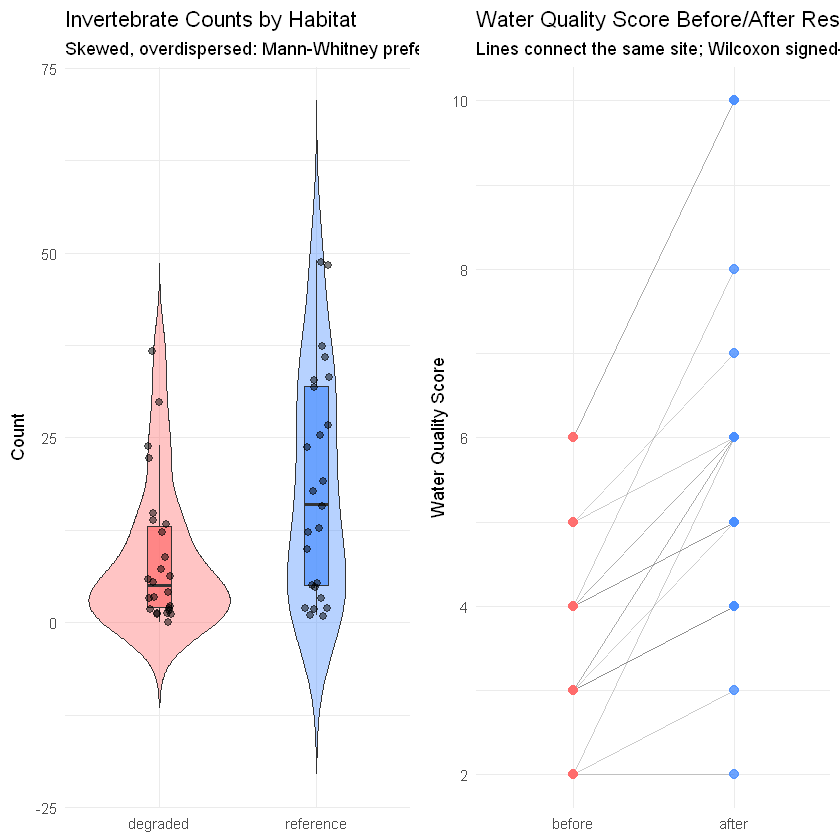

In [3]:
# ── Violin + boxplot: two independent groups ─────────────────────────────────
p1 <- ggplot(two_group, aes(x = habitat, y = count, fill = habitat)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.08, alpha = 0.5, size = 1.8) +
  scale_fill_manual(values = c(degraded = "#ff6b6b", reference = "#4a8fff")) +
  labs(title = "Invertebrate Counts by Habitat",
       subtitle = "Skewed, overdispersed: Mann-Whitney preferred over t-test",
       x = NULL, y = "Count") +
  theme_minimal() + theme(legend.position = "none")

# ── Paired before/after ───────────────────────────────────────────────────────
p2 <- paired_data %>%
  pivot_longer(c(before, after), names_to = "time", values_to = "score") %>%
  mutate(time = factor(time, levels = c("before", "after"))) %>%
  ggplot(aes(x = time, y = score, group = site)) +
  geom_line(alpha = 0.4, color = "gray50") +
  geom_point(aes(color = time), size = 2.5, alpha = 0.8) +
  scale_color_manual(values = c(before = "#ff6b6b", after = "#4a8fff")) +
  labs(title = "Water Quality Score Before/After Restoration",
       subtitle = "Lines connect the same site; Wilcoxon signed-rank for paired data",
       x = NULL, y = "Water Quality Score") +
  theme_minimal() + theme(legend.position = "none")

gridExtra::grid.arrange(p1, p2, ncol = 2)

---

## Mann-Whitney U Test (Wilcoxon Rank-Sum)

In [4]:
# ── Base R: wilcox.test() ─────────────────────────────────────────────────────
mwu <- wilcox.test(
  count ~ habitat,
  data        = two_group,
  alternative = "two.sided",
  exact       = FALSE,   # use asymptotic approximation for n > ~25
                          # exact = TRUE for small samples without ties
  correct     = TRUE,    # continuity correction (Yates)
  conf.int    = TRUE     # returns Hodges-Lehmann estimate of location shift
)
print(mwu)
# W: Mann-Whitney U statistic (sum of ranks for group 1)
# p-value: significance
# conf.int: Hodges-Lehmann estimator — median of all pairwise differences
#           between the two groups; interpretable as median difference

# ── Effect size: rank-biserial correlation ────────────────────────────────────
# r = 1 - (2W)/(n1*n2); ranges -1 to 1
# |r| < 0.1: negligible; 0.1–0.3: small; 0.3–0.5: medium; > 0.5: large
eff <- effectsize::rank_biserial(
  count ~ habitat,
  data = two_group
)
print(eff)

# ── Exact test via coin package (for small samples or when ties exist) ────────
mwu_exact <- coin::wilcox_test(
  count ~ factor(habitat),
  data         = two_group,
  distribution = "exact"   # or "asymptotic", "approximate"
)
print(mwu_exact)


	Wilcoxon rank sum test with continuity correction

data:  count by habitat
W = 195.5, p-value = 0.02342
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -16.9999239  -0.9999699
sample estimates:
difference in location 
             -7.000006 

r (rank biserial) |         95% CI
----------------------------------
-0.37             | [-0.61, -0.07]

	Exact Wilcoxon-Mann-Whitney Test

data:  count by factor(habitat) (degraded, reference)
Z = -2.2762, p-value = 0.0222
alternative hypothesis: true mu is not equal to 0



---

## Wilcoxon Signed-Rank Test

In [5]:
# ── Base R: wilcox.test() with paired = TRUE ──────────────────────────────────
wsr <- wilcox.test(
  paired_data$after,
  paired_data$before,
  paired      = TRUE,
  alternative = "greater",  # testing: after > before
  exact       = FALSE,
  conf.int    = TRUE
)
print(wsr)
# V: sum of positive ranks (signed-rank statistic)
# Hodges-Lehmann estimate: pseudo-median of pairwise differences (within pairs)

# ── Sign test as a simpler alternative (no ranking, just direction) ───────────
# Counts how many pairs show improvement
n_pos <- sum(paired_data$diff > 0)
n_neg <- sum(paired_data$diff < 0)
n_ties <- sum(paired_data$diff == 0)
sign_p <- binom.test(n_pos, n_pos + n_neg, p = 0.5, alternative = "greater")$p.value

cat(sprintf("Sign test: %d improved, %d worsened, %d tied\n",
            n_pos, n_neg, n_ties))
cat(sprintf("Sign test p = %.4f\n", sign_p))
# Sign test is less powerful than Wilcoxon signed-rank (uses only direction,
# not magnitude) but robust to non-symmetry of differences

# ── Effect size: matched-rank biserial ───────────────────────────────────────
eff_paired <- effectsize::rank_biserial(
  paired_data$after,
  paired_data$before,
  paired = TRUE
)
print(eff_paired)


	Wilcoxon signed rank test with continuity correction

data:  paired_data$after and paired_data$before
V = 190, p-value = 5.708e-05
alternative hypothesis: true location shift is greater than 0
95 percent confidence interval:
 1.499966      Inf
sample estimates:
(pseudo)median 
      1.999969 

Sign test: 19 improved, 0 worsened, 1 tied
Sign test p = 0.0000
r (rank biserial) |       95% CI
--------------------------------
1                 | [1.00, 1.00]


---

## Checking the Key Assumption: Symmetry of Differences (Signed-Rank)

The Wilcoxon signed-rank test assumes the distribution of pairwise differences is **symmetric** around the median. If this is violated, use the sign test instead.

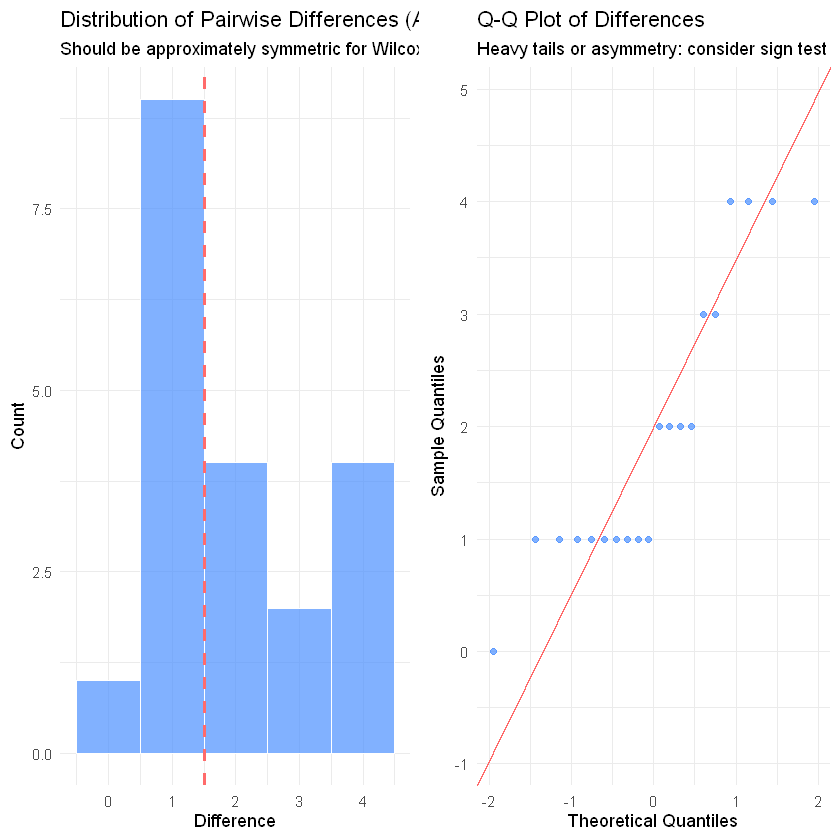

In [6]:
# ── Check symmetry of differences ────────────────────────────────────────────
p_sym <- ggplot(paired_data, aes(x = diff)) +
  geom_histogram(binwidth = 1, fill = "#4a8fff", alpha = 0.7, color = "white") +
  geom_vline(xintercept = median(paired_data$diff),
             linetype = "dashed", color = "#ff6b6b", linewidth = 1) +
  labs(title = "Distribution of Pairwise Differences (After - Before)",
       subtitle = "Should be approximately symmetric for Wilcoxon signed-rank to be valid",
       x = "Difference", y = "Count") +
  theme_minimal()

# ── Q-Q plot of differences ───────────────────────────────────────────────────
p_qq <- ggplot(paired_data, aes(sample = diff)) +
  stat_qq(color = "#4a8fff", alpha = 0.7) +
  stat_qq_line(color = "#ff6b6b", linewidth = 0.8) +
  labs(title = "Q-Q Plot of Differences",
       subtitle = "Heavy tails or asymmetry: consider sign test",
       x = "Theoretical Quantiles", y = "Sample Quantiles") +
  theme_minimal()

gridExtra::grid.arrange(p_sym, p_qq, ncol = 2)

---

## Reporting Results

In [7]:
# ── Summary output ────────────────────────────────────────────────────────────
cat("=== Mann-Whitney U ===\n")
cat(sprintf("W = %.0f, p = %.4f\n", mwu$statistic, mwu$p.value))
cat(sprintf("Hodges-Lehmann estimate: %.2f [%.2f, %.2f]\n",
            mwu$estimate, mwu$conf.int[1], mwu$conf.int[2]))
cat(sprintf("Rank-biserial r = %.3f [%.3f, %.3f]\n",
            eff$r_rank_biserial, eff$CI_low, eff$CI_high))

cat("\n=== Wilcoxon Signed-Rank ===\n")
cat(sprintf("V = %.0f, p = %.4f\n", wsr$statistic, wsr$p.value))
cat(sprintf("Hodges-Lehmann estimate: %.2f [%.2f, %.2f]\n",
            wsr$estimate, wsr$conf.int[1], wsr$conf.int[2]))

# Standard reporting format:
# Mann-Whitney: "Reference sites had significantly higher invertebrate counts
#   than degraded sites (Mann-Whitney U = XXX, p = .XXX; Hodges-Lehmann
#   estimate = X.X, 95% CI [X.X, X.X]; rank-biserial r = .XX)."
#
# Signed-rank: "Water quality scores increased significantly following
#   restoration (Wilcoxon signed-rank: V = XXX, p = .XXX; median
#   improvement = X.X [X.X, X.X])."
#
# Always report: test statistic, p-value, effect size, AND the
# Hodges-Lehmann estimate (not just medians of each group)

=== Mann-Whitney U ===
W = 196, p = 0.0234
Hodges-Lehmann estimate: -7.00 [-17.00, -1.00]
Rank-biserial r = -0.374 [-0.615, -0.070]

=== Wilcoxon Signed-Rank ===
V = 190, p = 0.0001
Hodges-Lehmann estimate: 2.00 [1.50, Inf]


---

## Common Pitfalls

**1. Describing the test as comparing medians**  
The Mann-Whitney test compares the full distributions, not just their medians. Two groups can have the same median but different Mann-Whitney results if their distributions have different shapes. The correct description is: tests stochastic equality — whether one group tends to produce higher values than the other.

**2. Not reporting effect size**  
A p-value alone is uninterpretable. Always report the rank-biserial correlation r (for Mann-Whitney) and the Hodges-Lehmann estimate (for both tests) as the effect size and location shift respectively.

**3. Using exact = TRUE when ties are present**  
The exact test assumes no ties. When ties exist (especially with ordinal data), use `exact = FALSE` with the asymptotic approximation, or use the `coin` package which handles ties properly.

**4. Defaulting to nonparametric tests because data 'look non-normal'**  
The t-test is robust to moderate non-normality for n ≥ 30 due to the CLT. Nonparametric tests have lower power when the t-test assumptions hold. Use nonparametric tests when: sample is small AND non-normality is clear, data are ordinal, or outliers cannot be addressed otherwise.

**5. Forgetting that the signed-rank test requires symmetric differences**  
If the differences are skewed, the signed-rank test is not valid. Check with a histogram of differences and use the sign test if symmetry cannot be assumed.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*